# 电影圈数据

In [53]:
import pandas as pd
import numpy as np
import networkx as nx
import scipy
import matplotlib.pyplot as plt
from networkx.algorithms import bipartite

In [2]:
import sys
sys.path.append("..")

# 数据处理

## 原始数据

In [3]:
df_raw = pd.read_csv("../data/cast/dwd_cast_works.csv")
df_raw.head()

,cast_id,cast_name,gender,movie_id,k_role,is_main_cast,index,id,k_title,k_type,...,k_genres,is_rating,rating_num,rating_people,k_rating_people,rating_index,k_movie_id,k_cast_id,uid,portray
0,1007816,凌玲,女,10767181,演员,是,5,10767181,妙手千金,电影,...,喜剧/动作,无评分,NaN,暂无评分,NaN,NaN,21534411,2015681,1,NaN
1,1003352,金焰,男,10618303,演员,是,1,10618303,失去的爱情,电影,...,爱情,无评分,NaN,暂无评分,NaN,NaN,21236655,2006753,2,NaN
2,1003352,金焰,男,10601198,演员,是,1,10601198,人道,电影,...,剧情,无评分,NaN,暂无评分,NaN,NaN,21202445,2006753,3,NaN
3,1003352,金焰,男,10566664,演员,是,2,10566664,母亲,电影,...,剧情,无评分,NaN,暂无评分,NaN,NaN,21133377,2006753,4,老邓
4,1013885,阿美莉嘉·奥利沃,女,10727641,演员,是,21,10727641,碟中谍5：神秘国度,电影,...,动作/惊悚/冒险,有评分,7.8,292193,292193.0,1510.0,21455331,2027819,5,Turandot


## 数据筛选
过滤条件
1. 电影
2. 有评分
3. 地区含中国

In [4]:
df_movie = df_raw.loc[
    (df_raw['k_type'] == '电影') &
    (df_raw['k_region'].str.contains('中国'))].copy()
# 仅保留演员，导演数
df_movie = df_movie[df_movie['k_role'].isin(['演员', '导演'])]
df_movie = df_movie.reset_index(drop=True).copy(deep=True)
# 添加新的movie_id_m列
df_movie['movie_id_m'] = df_movie['k_movie_id'].apply(lambda x: 'm' + str(x))
df_movie

,cast_id,cast_name,gender,movie_id,k_role,is_main_cast,index,id,k_title,k_type,...,is_rating,rating_num,rating_people,k_rating_people,rating_index,k_movie_id,k_cast_id,uid,portray,movie_id_m
0,1007816,凌玲,女,10767181,演员,是,5,10767181,妙手千金,电影,...,无评分,NaN,暂无评分,NaN,NaN,21534411,2015681,1,NaN,m21534411
1,1003352,金焰,男,10618303,演员,是,1,10618303,失去的爱情,电影,...,无评分,NaN,暂无评分,NaN,NaN,21236655,2006753,2,NaN,m21236655
2,1003352,金焰,男,10601198,演员,是,1,10601198,人道,电影,...,无评分,NaN,暂无评分,NaN,NaN,21202445,2006753,3,NaN,m21202445
3,1003352,金焰,男,10566664,演员,是,2,10566664,母亲,电影,...,无评分,NaN,暂无评分,NaN,NaN,21133377,2006753,4,老邓,m21133377
4,1003424,蒋君超,男,10777680,演员,是,2,10777680,影坛风月,电影,...,无评分,NaN,暂无评分,NaN,NaN,21555409,2006897,6,NaN,m21555409
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
224720,1370230,张巨光,男,3542526,演员,否,999,3542526,保卫胜利果实,电影,...,无评分,NaN,暂无评分,NaN,NaN,7085101,2740509,604126,村民,m7085101
224721,1431712,邓祥,男,1466295,演员,否,999,1466295,倚天屠龙记（上集）,电影,...,无评分,NaN,暂无评分,NaN,NaN,2932639,2863473,604127,史镖头,m2932639
224722,27496534,刘芊蒂,女,2337597,演员,是,2,2337597,操行零分,电影,...,有评分,7.0,211,211.0,38.0,4675243,54993117,604128,NaN,m4675243
224723,27565771,董亚春,女,2270516,导演,是,2,2270516,八月一日,电影,...,有评分,6.4,1123,1123.0,85.0,4541081,55131591,604130,NaN,m4541081


## 影人职责合并

In [5]:
# 合并影人职责
df_cast = df_movie[['k_cast_id', 'cast_name', 'k_role']].drop_duplicates()
df_cast_agg = df_cast.groupby(['k_cast_id', 'cast_name'])['k_role'].apply(lambda x: '/'.join(sorted(x.unique()))).reset_index()
df_cast_agg

,k_cast_id,cast_name,k_role
0,2000437,李香凝,演员
1,2000457,吉娜·卡拉诺,演员
2,2000515,理查德·格里克,演员
3,2000941,司汗,演员
4,2001011,凯文·格劳特,导演
...,...,...,...
42248,75617721,吴铃山,演员
42249,75617969,特蕾沙,演员
42250,75618493,何宥辰,演员
42251,75622879,祖丽米热,演员


In [6]:
df_movie['cast_role_agg'] = df_movie['k_cast_id'].map(
    df_cast_agg.set_index('k_cast_id')['k_role']
)
df_movie

,cast_id,cast_name,gender,movie_id,k_role,is_main_cast,index,id,k_title,k_type,...,rating_num,rating_people,k_rating_people,rating_index,k_movie_id,k_cast_id,uid,portray,movie_id_m,cast_role_agg
0,1007816,凌玲,女,10767181,演员,是,5,10767181,妙手千金,电影,...,NaN,暂无评分,NaN,NaN,21534411,2015681,1,NaN,m21534411,演员
1,1003352,金焰,男,10618303,演员,是,1,10618303,失去的爱情,电影,...,NaN,暂无评分,NaN,NaN,21236655,2006753,2,NaN,m21236655,演员
2,1003352,金焰,男,10601198,演员,是,1,10601198,人道,电影,...,NaN,暂无评分,NaN,NaN,21202445,2006753,3,NaN,m21202445,演员
3,1003352,金焰,男,10566664,演员,是,2,10566664,母亲,电影,...,NaN,暂无评分,NaN,NaN,21133377,2006753,4,老邓,m21133377,演员
4,1003424,蒋君超,男,10777680,演员,是,2,10777680,影坛风月,电影,...,NaN,暂无评分,NaN,NaN,21555409,2006897,6,NaN,m21555409,导演/演员
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
224720,1370230,张巨光,男,3542526,演员,否,999,3542526,保卫胜利果实,电影,...,NaN,暂无评分,NaN,NaN,7085101,2740509,604126,村民,m7085101,演员
224721,1431712,邓祥,男,1466295,演员,否,999,1466295,倚天屠龙记（上集）,电影,...,NaN,暂无评分,NaN,NaN,2932639,2863473,604127,史镖头,m2932639,演员
224722,27496534,刘芊蒂,女,2337597,演员,是,2,2337597,操行零分,电影,...,7.0,211,211.0,38.0,4675243,54993117,604128,NaN,m4675243,演员
224723,27565771,董亚春,女,2270516,导演,是,2,2270516,八月一日,电影,...,6.4,1123,1123.0,85.0,4541081,55131591,604130,NaN,m4541081,导演


In [7]:
df_movie[df_movie['cast_name'] == '张艺谋']

,cast_id,cast_name,gender,movie_id,k_role,is_main_cast,index,id,k_title,k_type,...,rating_num,rating_people,k_rating_people,rating_index,k_movie_id,k_cast_id,uid,portray,movie_id_m,cast_role_agg
2234,27260166,张艺谋,男,1294963,导演,是,1,1294963,一个都不能少,电影,...,7.7,120767,120767.0,964.0,2589975,54520381,4242,NaN,m2589975,导演/演员
4017,27260166,张艺谋,男,35294995,演员,是,40,35294995,我和我的父辈,电影,...,6.9,175739,175739.0,1101.0,70590039,54520381,8991,电视台台长,m70590039,导演/演员
7580,27260166,张艺谋,男,1294007,导演,是,1,1294007,我的父亲母亲,电影,...,8.2,116620,116620.0,978.0,2588063,54520381,18378,NaN,m2588063,导演/演员
12782,27260166,张艺谋,男,1308070,演员,是,1,1308070,老井,电影,...,8.0,16354,16354.0,362.0,2616189,54520381,32540,孙旺泉,m2616189,导演/演员
17992,27260166,张艺谋,男,26694491,导演,是,1,26694491,大红灯笼高高挂,电影,...,8.8,3372,3372.0,172.0,53389031,54520381,46511,NaN,m53389031,导演/演员
19694,27260166,张艺谋,男,1297879,演员,否,999,1297879,大阅兵,电影,...,6.8,1946,1946.0,115.0,2595807,54520381,51101,军官,m2595807,导演/演员
48988,27260166,张艺谋,男,35215390,导演,是,1,35215390,狙击手,电影,...,7.7,340264,340264.0,1619.0,70430829,54520381,130724,NaN,m70430829,导演/演员
48990,27260166,张艺谋,男,33447633,导演,是,1,33447633,坚如磐石,电影,...,6.0,344998,344998.0,1439.0,66895315,54520381,130736,NaN,m66895315,导演/演员
61266,27260166,张艺谋,男,1296436,演员,是,8,1296436,有话好好说,电影,...,8.3,170972,170972.0,1191.0,2592921,54520381,163429,收废品的,m2592921,导演/演员
61267,27260166,张艺谋,男,1296436,导演,是,1,1296436,有话好好说,电影,...,8.3,170972,170972.0,1191.0,2592921,54520381,163430,NaN,m2592921,导演/演员


## 有评分数据

In [15]:
df_movie_rated = df_movie[df_movie['is_rating'] == '有评分'].copy()
df_movie_rated = df_movie_rated.reset_index(drop=True).copy(deep=True)
df_movie_rated

,cast_id,cast_name,gender,movie_id,k_role,is_main_cast,index,id,k_title,k_type,...,rating_num,rating_people,k_rating_people,rating_index,k_movie_id,k_cast_id,uid,portray,movie_id_m,cast_role_agg
0,1017182,陈燕燕,女,10771202,演员,是,1,10771202,深闺疑云,电影,...,7.8,92,92.0,27.0,21542453,2034413,54,赵兰,m21542453,演员
1,1043845,刘志荣,男,10581318,演员,是,11,10581318,四大家族之龙虎兄弟,电影,...,7.8,2290,2290.0,134.0,21162685,2087739,75,NaN,m21162685,导演/演员
2,1050373,茅瑛,女,10573512,演员,是,1,10573512,鬼娘子,电影,...,5.8,235,235.0,37.0,21147073,2100795,77,NaN,m21147073,演员
3,1124360,利智,女,10581318,演员,是,3,10581318,四大家族之龙虎兄弟,电影,...,7.8,2290,2290.0,134.0,21162685,2248769,92,NaN,m21162685,演员
4,1315281,卢庆辉,男,10490155,演员,是,1,10490155,衰鬼抓狂,电影,...,5.8,121,121.0,26.0,20980359,2630611,156,NaN,m20980359,演员
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100882,27541325,张世,男,1298203,演员,是,2,1298203,国道封闭,电影,...,7.9,146,146.0,34.0,2596455,55082699,604105,NaN,m2596455,导演/演员
100883,27517568,林迪安,男,1300498,演员,否,999,1300498,百变星君,电影,...,7.7,246162,246162.0,1377.0,2601045,55035185,604118,穿斑马服君,m2601045,演员
100884,27541395,韩鹏翼,男,24695588,演员,是,2,24695588,逆袭,电影,...,5.1,674,674.0,59.0,49391225,55082839,604119,NaN,m49391225,演员
100885,27496534,刘芊蒂,女,2337597,演员,是,2,2337597,操行零分,电影,...,7.0,211,211.0,38.0,4675243,54993117,604128,NaN,m4675243,演员


# 数据统计

## 年度数据

In [9]:
# 按年统计每年的电影数量
df_count_by_year = df_movie.groupby('k_movie_year')['movie_id_m'].nunique().reset_index()
df_count_by_year.columns = ['year', 'movie_count']
df_count_by_year = df_count_by_year.sort_values('year')
df_count_by_year

,year,movie_count
0,1905,2
1,1909,2
2,1913,14
3,1916,1
4,1919,1
...,...,...
106,2021,1547
107,2022,1265
108,2023,1254
109,2024,1099


/opt/anaconda3/envs/net_charts/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 30005 (\N{CJK UNIFIED IDEOGRAPH-7535}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/envs/net_charts/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 24433 (\N{CJK UNIFIED IDEOGRAPH-5F71}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/envs/net_charts/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/envs/net_charts/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 37327 (\N{CJK UNIFIED IDEOGRAPH-91CF}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/envs/net_charts/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: User

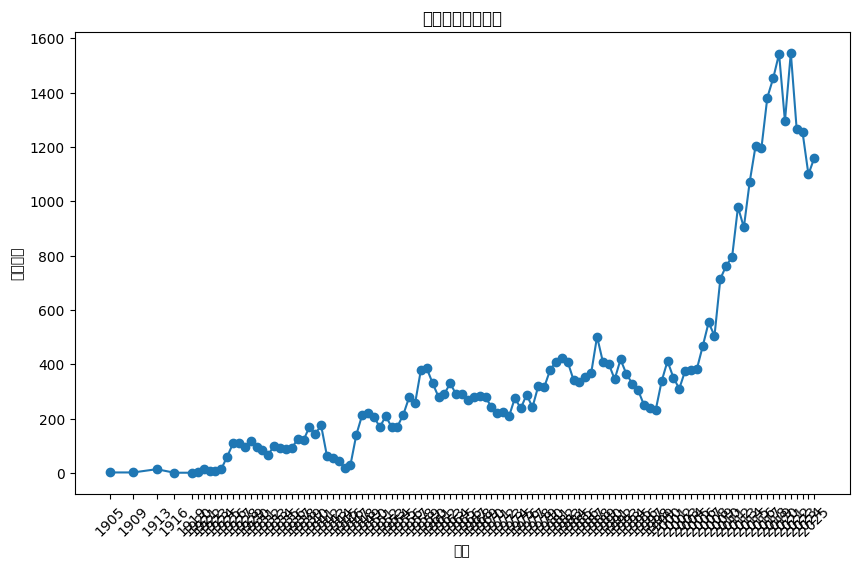

In [10]:
# 绘图
plt.figure(figsize=(10, 6))
plt.plot(df_count_by_year['year'], df_count_by_year['movie_count'], marker='o')
plt.title('年度电影数量统计')
plt.xlabel('年份')
plt.ylabel('电影数量')
plt.xticks(df_count_by_year['year'], rotation=45)
# plt.tight_layout()
plt.show()

# 图对象

In [11]:
G = nx.from_pandas_edgelist(
    df_movie,
    source='k_cast_id',
    target='movie_id_m',
    edge_attr=True,
    create_using=nx.Graph()
)
G.number_of_nodes(), G.number_of_edges()

(83402, 223085)

In [12]:
# 子图数量
len(list(nx.connected_components(G)))

2350

In [13]:
# 最大联通分支
largest_cc = max(nx.connected_components(G), key=len)
G_largest = G.subgraph(largest_cc).copy()
G_largest.number_of_nodes(), G_largest.number_of_edges()

(76852, 218794)

In [16]:
# 删除度为1的节点
G_pruned = G_largest.copy()
nodes_to_remove = [node for node, degree in dict(G_pruned.degree()).items() if degree == 1]
G_pruned.remove_nodes_from(nodes_to_remove)
G_pruned.number_of_nodes(), G_pruned.number_of_edges()    

(53993, 195935)

## 二分图

In [19]:
# 二分图
nx.is_bipartite(G_pruned)

True

## 绘图

In [17]:
def draw_network_largest_component(G):
    """绘制网络图"""
    # pos = nx.spring_layout(G, seed=42)
    # largest connected component
    components = nx.connected_components(G)
    largest_component = max(components, key=len)
    H = G.subgraph(largest_component)
    # compute centrality
    centrality = nx.betweenness_centrality(H, k=10, endpoints=True)
    # compute community structure
    lpc = nx.community.label_propagation_communities(H)
    community_index = {n: i for i, com in enumerate(lpc) for n in com}
    #### draw graph ####
    fig, ax = plt.subplots(figsize=(20, 20))
    pos = nx.spring_layout(H, k=0.15, seed=4572321)
    node_color = [community_index[n] for n in H]
    node_size = [v * 20000 for v in centrality.values()]
    return nx.draw_networkx(
        H,
        pos=pos,
        with_labels=False,
        node_color=node_color,
        node_size=node_size,
        edge_color="gainsboro",
        alpha=0.4,
    )

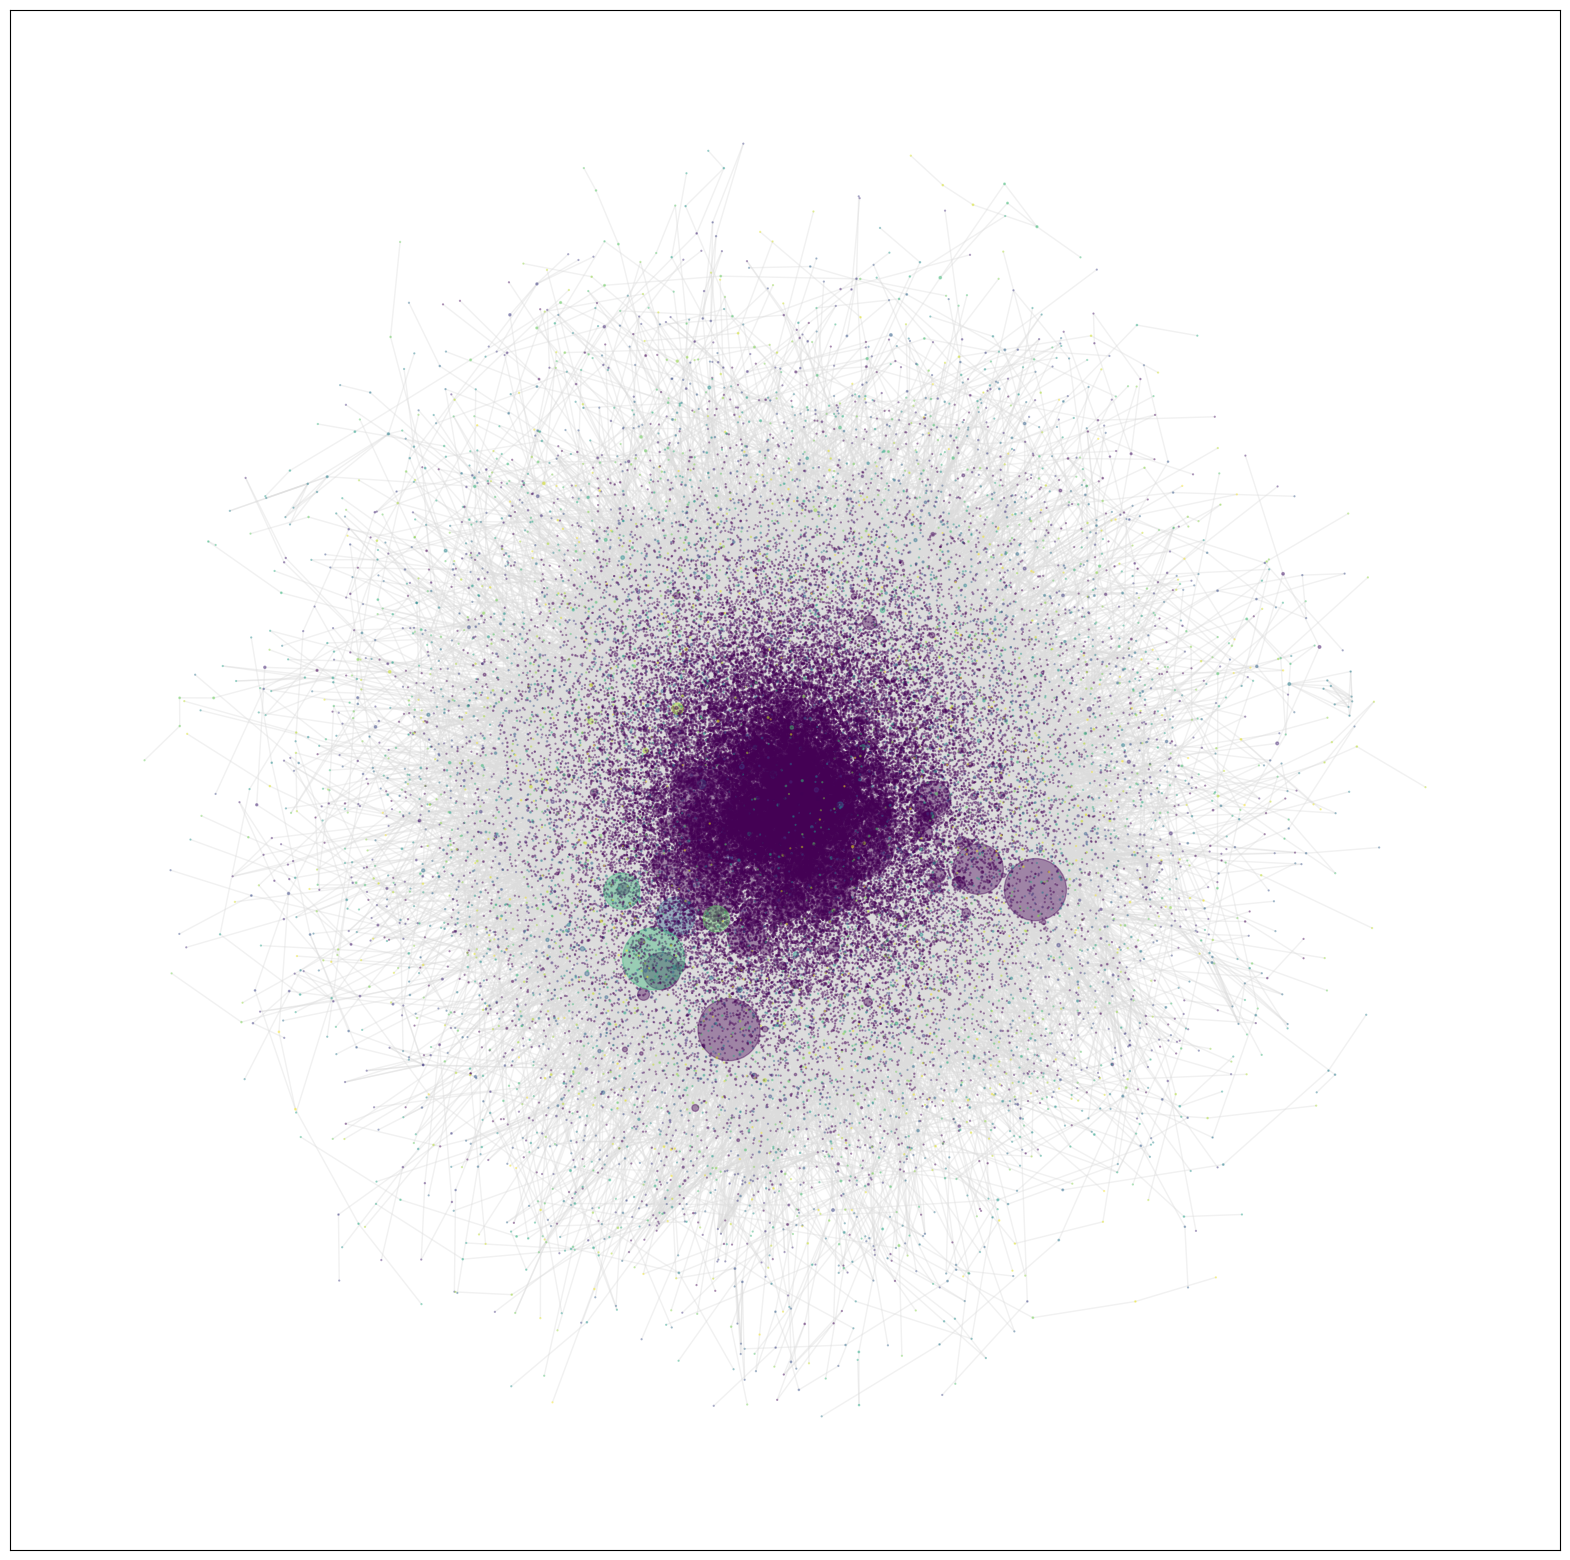

In [18]:
draw_network_largest_component(G_pruned)

In [25]:
def draw_network(G):
    """绘制网络图"""
    lpc = nx.community.label_propagation_communities(G)
    community_index = {n: i for i, com in enumerate(lpc) for n in com}
    #### draw graph ####
    fig, ax = plt.subplots(figsize=(20, 20))
    pos = nx.spring_layout(G, k=0.15, seed=4572321)
    node_color = [community_index[n] for n in G]
    return nx.draw_networkx(
        G,
        pos=pos,
        with_labels=False,
        node_color=node_color,
        edge_color="gainsboro",
        node_size=1,
        alpha=0.4,
    )

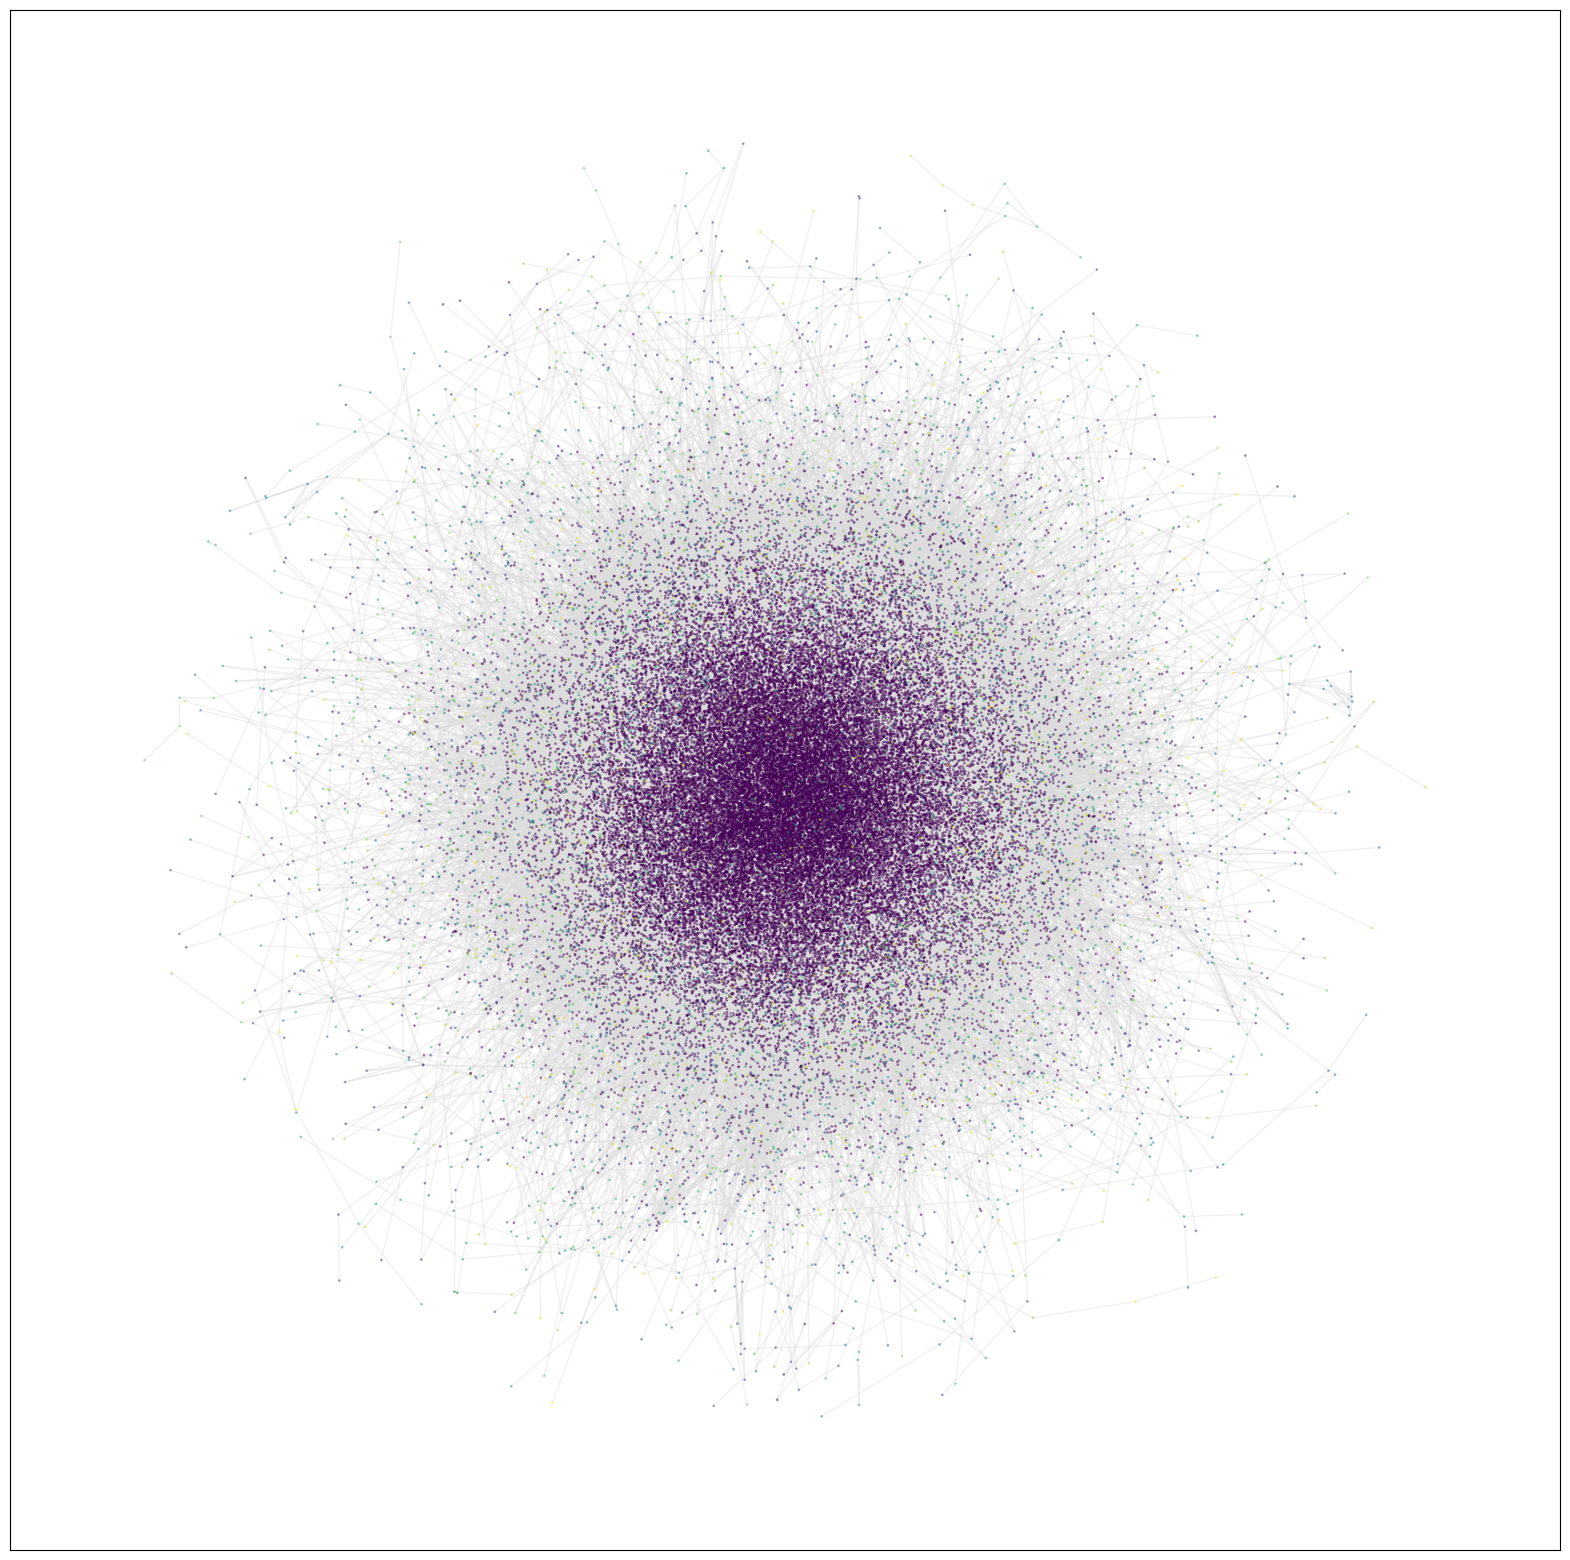

In [26]:
draw_network(G_pruned)

# 图特征

## 定军山

In [21]:
df_movie[df_movie['k_title'] == '定军山']

,cast_id,cast_name,gender,movie_id,k_role,is_main_cast,index,id,k_title,k_type,...,rating_num,rating_people,k_rating_people,rating_index,k_movie_id,k_cast_id,uid,portray,movie_id_m,cast_role_agg
8333,27495236,安战军,男,1915339,导演,是,1,1915339,定军山,电影,...,5.5,462,462.0,50.0,3830727,54990521,20293,NaN,m3830727,导演
13236,27236475,刘冰鉴,男,30221273,导演,是,1,30221273,定军山,电影,...,NaN,暂无评分,NaN,NaN,60442595,54472999,33777,NaN,m60442595,导演
16281,27563977,郝荣光,男,1915339,演员,是,4,1915339,定军山,电影,...,5.5,462,462.0,50.0,3830727,55128003,41921,刘仲伦,m3830727,演员
31460,27541002,景珂,女,1915339,演员,是,5,1915339,定军山,电影,...,5.5,462,462.0,50.0,3830727,55082053,83143,雅琦格格,m3830727,演员
65268,27484680,郭晓晓,女,1915339,演员,是,9,1915339,定军山,电影,...,5.5,462,462.0,50.0,3830727,54969409,174412,福晋,m3830727,演员
76223,1321583,曲宁,女,1915339,演员,是,8,1915339,定军山,电影,...,5.5,462,462.0,50.0,3830727,2643215,204067,景泰妻,m3830727,演员
92094,1329956,任景丰,男,1915340,导演,是,1,1915340,定军山,电影,...,9.4,910,910.0,92.0,3830729,2659961,246804,NaN,m3830729,导演
94648,27480802,赵滨,男,1915339,演员,是,7,1915339,定军山,电影,...,5.5,462,462.0,50.0,3830727,54961653,253764,富贵,m3830727,演员
137196,1379969,谭元寿,男,1915339,演员,是,2,1915339,定军山,电影,...,5.5,462,462.0,50.0,3830727,2759987,368175,谭鑫培,m3830727,演员
148265,27481220,杨立新,男,1915339,演员,是,1,1915339,定军山,电影,...,5.5,462,462.0,50.0,3830727,54962489,397826,任景丰,m3830727,导演/演员


In [22]:
root_id = 'm3830729'

In [24]:
root_id in  G_pruned.nodes

False

## 图片测试

In [30]:
df_2024 = df_movie_rated[df_movie_rated['k_movie_year'] == 2024].copy()
G_2024 = nx.from_pandas_edgelist(
    df_2024,
    source='k_cast_id',
    target='movie_id_m',
    edge_attr=True,
    create_using=nx.Graph()
)
G_2024.number_of_nodes(), G_2024.number_of_edges()

(1769, 2059)

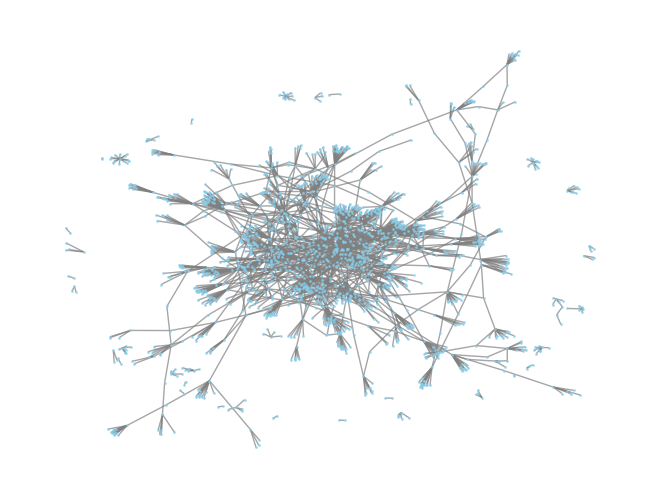

In [40]:
pos = nx.spring_layout(G_2024, seed=42)
nx.draw(G_2024, pos, with_labels=False, node_size=1, node_color='skyblue', edge_color='gray', alpha=0.7)

In [41]:
pos

{54965695: array([0.00191756, 0.10014373]),
 'm70054483': array([0.13557738, 0.08062082]),
 54992385: array([-0.35204558,  0.04933621]),
 'm73135229': array([-0.28047475,  0.02567237]),
 54969649: array([0.04802303, 0.24196844]),
 'm73307885': array([0.04854264, 0.16376218]),
 55108007: array([ 0.03092477, -0.78806118]),
 'm70345453': array([ 0.04716232, -0.78950109]),
 55119013: array([0.17051588, 0.04601342]),
 'm72162237': array([0.15571879, 0.11564684]),
 55095059: array([-0.18388808,  0.02067919]),
 'm70485793': array([-0.15689873,  0.05117756]),
 55108169: array([-0.17239512,  0.52360416]),
 'm74145739': array([-0.17254153,  0.43272312]),
 54485743: array([0.19640536, 0.01935201]),
 'm54195939': array([0.36788264, 0.06329375]),
 55175109: array([0.71943871, 0.33293752]),
 'm72997463': array([0.71527504, 0.32164337]),
 55163271: array([ 0.24528975, -0.34378403]),
 'm69964649': array([ 0.19653496, -0.26955281]),
 55151177: array([-0.0545634 ,  0.16353007]),
 'm73145265': array([-0.

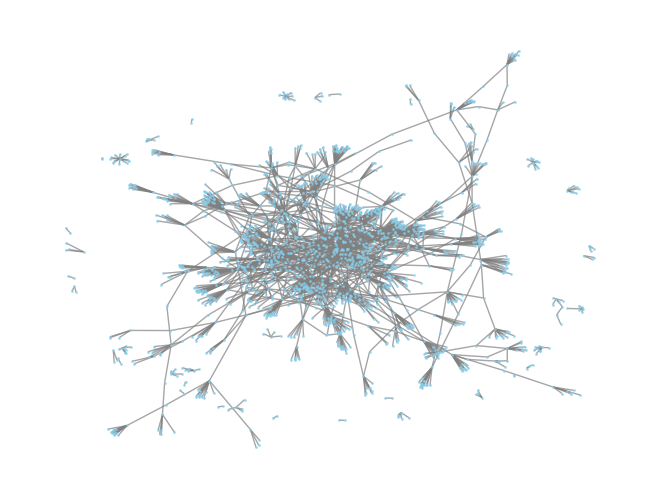

In [42]:
# 对pos的x坐标都乘以2
for key in pos:
    pos[key][0] *= 2
nx.draw(G_2024, pos, with_labels=False, node_size=1, node_color='skyblue', edge_color='gray', alpha=0.7)

In [43]:
pos

{54965695: array([0.00383513, 0.10014373]),
 'm70054483': array([0.27115475, 0.08062082]),
 54992385: array([-0.70409117,  0.04933621]),
 'm73135229': array([-0.56094951,  0.02567237]),
 54969649: array([0.09604606, 0.24196844]),
 'm73307885': array([0.09708527, 0.16376218]),
 55108007: array([ 0.06184954, -0.78806118]),
 'm70345453': array([ 0.09432464, -0.78950109]),
 55119013: array([0.34103177, 0.04601342]),
 'm72162237': array([0.31143757, 0.11564684]),
 55095059: array([-0.36777615,  0.02067919]),
 'm70485793': array([-0.31379745,  0.05117756]),
 55108169: array([-0.34479025,  0.52360416]),
 'm74145739': array([-0.34508306,  0.43272312]),
 54485743: array([0.39281073, 0.01935201]),
 'm54195939': array([0.73576527, 0.06329375]),
 55175109: array([1.43887741, 0.33293752]),
 'm72997463': array([1.43055009, 0.32164337]),
 55163271: array([ 0.49057951, -0.34378403]),
 'm69964649': array([ 0.39306992, -0.26955281]),
 55151177: array([-0.1091268 ,  0.16353007]),
 'm73145265': array([-0.

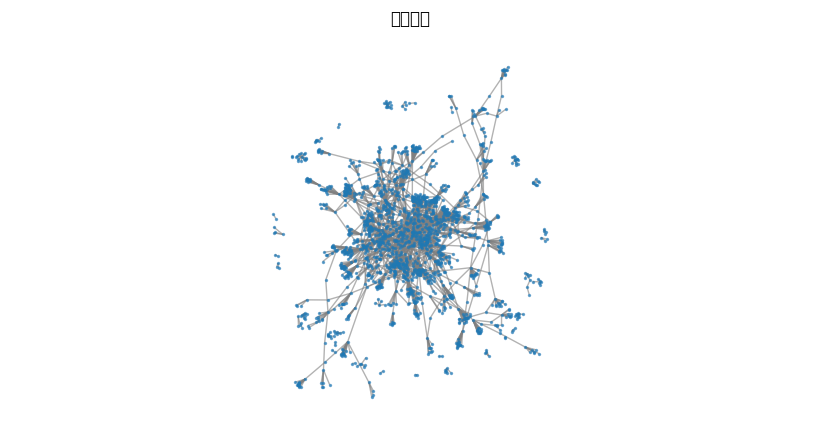

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


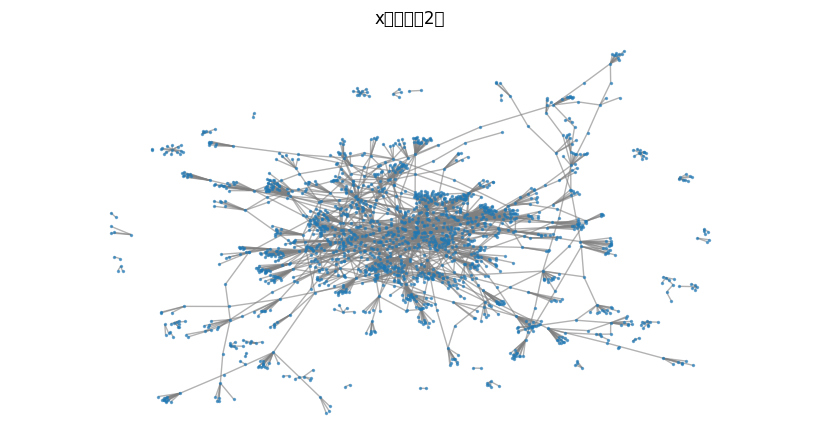

In [48]:
pos = nx.spring_layout(G_2024, seed=42)

plt.figure(figsize=(8,4))

# 第一次绘图
nx.draw(G_2024, pos, node_size=2, edge_color='gray', alpha=0.6)
plt.title("原始布局")
plt.axis('equal')
plt.show()

# 第二次绘图：x 坐标乘2
for k in pos:
    pos[k][0] *= 2

plt.figure(figsize=(8,4))
nx.draw(G_2024, pos, node_size=2, edge_color='gray', alpha=0.6)
plt.title("x方向放大2倍")
plt.axis('equal')

# 固定坐标范围，使得 matplotlib 不再自动缩放
x_vals, y_vals = zip(*pos.values())
plt.xlim(min(x_vals)-0.1, max(x_vals)+0.1)
plt.ylim(min(y_vals)-0.1, max(y_vals)+0.1)

plt.show()

# 年代数据

In [49]:
df_movie_1945 = df_movie[df_movie['k_movie_year'] <= 1945].copy()
df_movie_1945

,cast_id,cast_name,gender,movie_id,k_role,is_main_cast,index,id,k_title,k_type,...,rating_num,rating_people,k_rating_people,rating_index,k_movie_id,k_cast_id,uid,portray,movie_id_m,cast_role_agg
2,1003352,金焰,男,10601198,演员,是,1,10601198,人道,电影,...,NaN,暂无评分,NaN,NaN,21202445,2006753,3,NaN,m21202445,演员
4,1003424,蒋君超,男,10777680,演员,是,2,10777680,影坛风月,电影,...,NaN,暂无评分,NaN,NaN,21555409,2006897,6,NaN,m21555409,导演/演员
5,1003424,蒋君超,男,10771201,演员,是,3,10771201,血肉长城,电影,...,NaN,暂无评分,NaN,NaN,21542451,2006897,7,NaN,m21542451,导演/演员
7,1001284,韩兰根,男,10599962,演员,是,1,10599962,无愁君子,电影,...,NaN,暂无评分,NaN,NaN,21199973,2002617,10,NaN,m21199973,导演/演员
8,1007983,黄耐霜,女,10608345,演员,是,4,10608345,女人,电影,...,NaN,暂无评分,NaN,NaN,21216739,2016015,11,王意芳,m21216739,演员
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
224637,1401443,邵素霞,女,5975333,演员,是,2,5975333,苦儿流浪记,电影,...,NaN,暂无评分,NaN,NaN,11950715,2802935,603902,NaN,m11950715,演员
224671,1361639,张琬,女,26425589,演员,否,999,26425589,碧海青天,电影,...,NaN,暂无评分,NaN,NaN,52851227,2723327,603976,NaN,m52851227,演员
224683,1315618,田烈,男,20495666,演员,否,999,20495666,青年中国,电影,...,NaN,暂无评分,NaN,NaN,40991381,2631285,604010,老郑,m40991381,演员
224696,1400546,唐雪倩,女,30320247,演员,是,1,30320247,泥土黄金,电影,...,NaN,暂无评分,NaN,NaN,60640543,2801141,604045,NaN,m60640543,演员


In [50]:
movie_num_1945 = df_movie_1945['movie_id_m'].nunique()
movie_num_1945

2092

In [51]:
G_1945 = nx.from_pandas_edgelist(
    df_movie_1945,
    source='k_cast_id',
    target='movie_id_m',
    edge_attr=True,
    create_using=nx.Graph()     
)
G_1945.number_of_nodes(), G_1945.number_of_edges()

(3770, 11009)

In [52]:
# 二分
nx.is_bipartite(G_1945)


True

In [65]:
cast_ids_1945 = df_movie_1945['k_cast_id'].unique().tolist()

In [73]:
G_1945_bip = bipartite.projected_graph(G_1945, G_1945.nodes)

In [75]:
G_1945_movie = G_1945_bip.copy()
G_1945_movie.remove_nodes_from(cast_ids_1945)

In [77]:
G_1945_movie.number_of_nodes()

2092

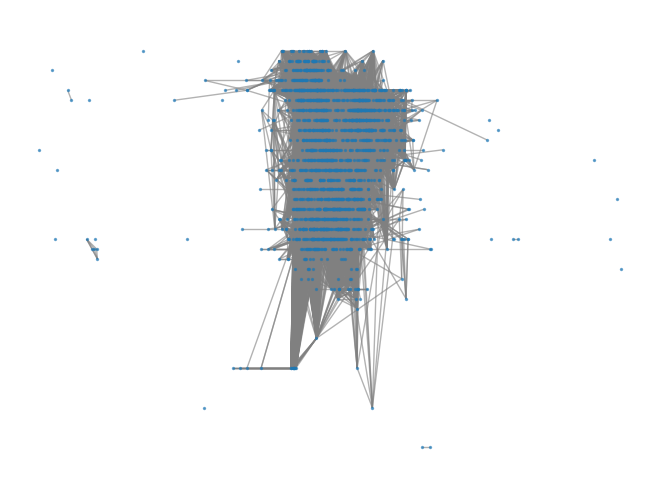

In [85]:
pos = nx.spring_layout(G_1945_movie, seed=42)
for k in pos:
    pos[k][1] = df_movie_1945[df_movie_1945['movie_id_m'] == k]['k_movie_year'].values[0]
    pos[k][0] *= 1945
nx.draw(G_1945_movie, pos, node_size=2, edge_color='gray', alpha=0.6)

In [82]:
df_movie_1945['k_movie_year'].min(), df_movie_1945['k_movie_year'].max()

(np.int64(1905), np.int64(1945))

In [87]:
df_movie_1945[df_movie_1945['k_movie_year'] == 1905]

,cast_id,cast_name,gender,movie_id,k_role,is_main_cast,index,id,k_title,k_type,...,rating_num,rating_people,k_rating_people,rating_index,k_movie_id,k_cast_id,uid,portray,movie_id_m,cast_role_agg
81630,1346511,谭鑫培,男,1915341,演员,是,1,1915341,长坂坡,电影,...,NaN,暂无评分,NaN,NaN,3830731,2693071,218636,赵云,m3830731,演员
92094,1329956,任景丰,男,1915340,导演,是,1,1915340,定军山,电影,...,9.4,910,910.0,92.0,3830729,2659961,246804,NaN,m3830729,导演
137485,1329956,任景丰,男,1915341,导演,是,1,1915341,长坂坡,电影,...,NaN,暂无评分,NaN,NaN,3830731,2659961,368937,NaN,m3830731,导演
